# Creating the CNN
We will be using a Convolutional Neural Network to predict if audio has been deepfaked.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load .npz file containing spectrograms
data = np.load('processed_data.npz')
X_train, y_train = data['x_train'], data['y_train']
X_val, y_val = data['x_val'], data['y_val']
X_test, y_test = data['x_test'], data['y_test']

print(f"Imported Data. Training on {X_train.shape[0]} samples of {X_train.shape[1:]}")

Imported Data. Training on 13956 samples of (128, 44, 2)


# Create the Model



In [2]:
from tensorflow.keras import layers, models

def build_robust_cnn(input_shape):
    model = models.Sequential()

    # --- Block 1 ---
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3))) 
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # --- Block 2 ---
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.SpatialDropout2D(0.3))

    # --- Flatten & Dense ---
    model.add(layers.Flatten())
    
    model.add(layers.Dense(64)) 
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.4)) 
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

# Use your new shape (128, 44, 2)
model = build_robust_cnn((128, 44, 2))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Slightly lower LR
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [3]:
print((X_train.shape))

(13956, 128, 44, 2)


In [4]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,          # Stop if no improvement for 3 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 107s 469ms/step - accuracy: 0.8458 - loss: 0.3438 - val_accuracy: 0.8793 - val_loss: 0.2780
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 141s 465ms/step - accuracy: 0.9445 - loss: 0.1625 - val_accuracy: 0.9533 - val_loss: 0.1460
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 142s 467ms/step - accuracy: 0.9772 - loss: 0.1003 - val_accuracy: 0.9834 - val_loss: 0.0743
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 141s 460ms/step - accuracy: 0.9845 - loss: 0.0719 - val_accuracy: 0.9919 - val_loss: 0.0528
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 143s 466ms/step - accuracy: 0.9901 - loss: 0.0551 - val_accuracy: 0.9908 - val_loss: 0.0470
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 102s 468ms/step - accuracy: 0.9904 - loss: 0.0475 - val_accuracy: 0.9947 - val_loss: 0.0341
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 140s 460ms/step - accuracy: 0.9939 - loss: 0.0375 - val_accuracy: 0.9954 - val_loss: 0.0278
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 144s 468ms/step - accuracy: 0.9933 -

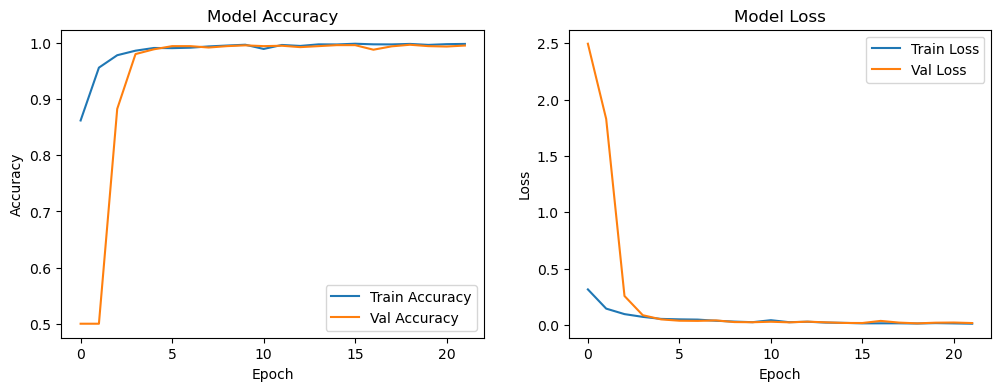

In [13]:
import matplotlib.pyplot as plt

# 1. Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Testing with the Test Data

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

34/34 - 2s - 49ms/step - accuracy: 0.5083 - loss: 2.1288

Final Test Accuracy: 50.83%


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


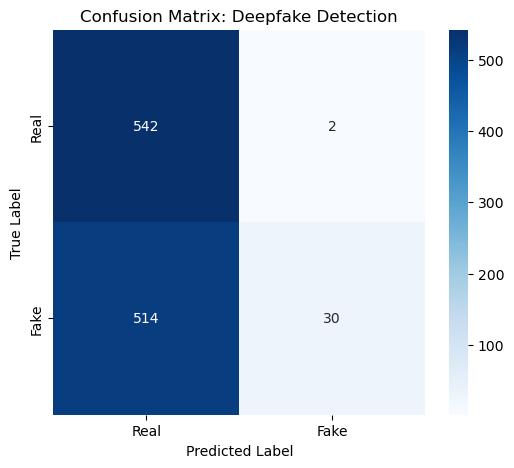

              precision    recall  f1-score   support

        Real       0.51      1.00      0.68       544
        Fake       0.94      0.06      0.10       544

    accuracy                           0.53      1088
   macro avg       0.73      0.53      0.39      1088
weighted avg       0.73      0.53      0.39      1088



In [84]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get the model's predictions (probabilities)
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to hard labels (0 or 1)
# Since we used a sigmoid output, anything > 0.5 is "Fake" (1)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Create the Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot it beautifully
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Deepfake Detection')
plt.show()

# 5. Print the full report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))